# **EXP04: Reranking Impact Analysis**

### Objective: Determine how much does reranking improve precision, and is the latency cost worth it?
### Variables: `None` vs `CrossEncoder` vs `BGE` vs `MXBAI`

```
Entities: FixedChunker, all-MiniLM-L6-v2, Dense Retriever
```



#### GPU Check

In [1]:
import torch

print("=" * 50)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

CUDA Available: True
GPU: Tesla T4


#### Clone Repository

In [2]:
!git clone https://github.com/ver1619/rag-bench.git
%cd rag-bench


Cloning into 'rag-bench'...
remote: Enumerating objects: 261, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 261 (delta 28), reused 23 (delta 12), pack-reused 214 (from 1)
Receiving objects: 100% (261/261), 64.17 MiB | 32.08 MiB/s, done.
Resolving deltas: 100% (93/93), done.
/content/rag-bench


#### Dependencies

In [3]:
!pip install -q langchain-text-splitters nltk pymupdf sentence-transformers \
   torch qdrant-client rank-bm25 python-dotenv matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 38.5 MB/s eta 0:00:00


#### Qdrant Cloud Connection

In [4]:
from google.colab import userdata
from qdrant_client import QdrantClient

QDRANT_URL = userdata.get("QDRANT_URL")
QDRANT_API_KEY = userdata.get("QDRANT_API_KEY")

cloud_client = QdrantClient(
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY,
)

print("✅ Connected to Qdrant Cloud")

✅ Connected to Qdrant Cloud


#### 1. Build Pipeline + Index (Once)

In [5]:
import json
import time
from pathlib import Path

from src.pipeline.factory import create_pipeline_builder
from src.ingestion.service import ingest_documents
from src.indexing.service import IndexingService
from src.vectordb.qdrant import QdrantVectorStore

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
COLLECTION = "exp04_reranking"

# Write config
config_path = Path("data/metadata/config.json")
config_path.parent.mkdir(parents=True, exist_ok=True)
with config_path.open("w") as f:
    json.dump({"embedding_model": EMBEDDING_MODEL, "chunker": "fixed"}, f, indent=4)

# Build
builder = create_pipeline_builder(
    model_name=EMBEDDING_MODEL,
    chunker="fixed",
)

pipeline = builder.build()

# Patch vector store for Qdrant Cloud
vector_store = QdrantVectorStore.__new__(QdrantVectorStore)
vector_store.host = QDRANT_URL
vector_store.port = 6333
vector_store.client = cloud_client

# Index
indexer = IndexingService(
    vector_store=vector_store,
    collection_name=COLLECTION,
)

indexer.index(
    embeddings=pipeline.embeddings,
    overwrite=True,
)

print(f"✅ Indexed {len(pipeline.embeddings)} vectors into '{COLLECTION}'")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/241 [00:00<?, ?it/s]


Uploading 30742 embeddings in 121 batches...

[  1/121] Indexed 256 vectors
[  2/121] Indexed 256 vectors
[  3/121] Indexed 256 vectors
[  4/121] Indexed 256 vectors
[  5/121] Indexed 256 vectors
[  6/121] Indexed 256 vectors
[  7/121] Indexed 256 vectors
[  8/121] Indexed 256 vectors
[  9/121] Indexed 256 vectors
[ 10/121] Indexed 256 vectors
[ 11/121] Indexed 256 vectors
[ 12/121] Indexed 256 vectors
[ 13/121] Indexed 256 vectors
[ 14/121] Indexed 256 vectors
[ 15/121] Indexed 256 vectors
[ 16/121] Indexed 256 vectors
[ 17/121] Indexed 256 vectors
[ 18/121] Indexed 256 vectors
[ 19/121] Indexed 256 vectors
[ 20/121] Indexed 256 vectors
[ 21/121] Indexed 256 vectors
[ 22/121] Indexed 256 vectors
[ 23/121] Indexed 256 vectors
[ 24/121] Indexed 256 vectors
[ 25/121] Indexed 256 vectors
[ 26/121] Indexed 256 vectors
[ 27/121] Indexed 256 vectors
[ 28/121] Indexed 256 vectors
[ 29/121] Indexed 256 vectors
[ 30/121] Indexed 256 vectors
[ 31/121] Indexed 256 vectors
[ 32/121] Indexed 256 v

#### 2. Define Rerankers + Evaluate

In [6]:
from src.retrieval.factory import create_dense_retriever
from src.retrieval.pipeline import RetrievalPipeline

from src.rerankers.factory import (
    create_cross_encoder_reranker,
    create_bge_reranker,
    create_mxbai_reranker,
)

from src.evaluation.dataset import EvaluationDataset
from src.evaluation.latency import Latency
from src.evaluation.runner import EvaluationRunner
from src.evaluation.metrics import (
    RecallAtK,
    PrecisionAtK,
    MeanReciprocalRank,
    NormalizedDiscountedCumulativeGain,
)

embedder = builder.embedder
chunks = pipeline.chunks

retriever = create_dense_retriever(
    vector_store=vector_store,
    embedder=embedder,
    collection_name=COLLECTION,
)

rerankers = {
    "None": None,
    "CrossEncoder (ms-marco)": create_cross_encoder_reranker(),
    "BGE Reranker": create_bge_reranker(),
    "MXBAI Reranker": create_mxbai_reranker(),
}

metrics = [
    RecallAtK(),
    PrecisionAtK(),
    MeanReciprocalRank(),
    NormalizedDiscountedCumulativeGain(),
]

dataset = EvaluationDataset("data/queries/queries.json")

results = {}

for label, reranker in rerankers.items():

    print(f"\n{'='*60}")
    print(f"Reranker: {label}")
    print(f"{'='*60}")

    retrieval_pipeline = RetrievalPipeline(
        retriever=retriever,
        reranker=reranker,
    )

    runner = EvaluationRunner(
        retrieval_pipeline=retrieval_pipeline,
        dataset=dataset,
        metrics=metrics,
        latency=Latency(),
    )

    start = time.perf_counter()
    benchmark = runner.run(top_k=5)
    elapsed = time.perf_counter() - start

    s = benchmark.summary

    results[label] = {
        "Recall@5": s.recall,
        "Precision@5": s.precision,
        "MRR": s.mrr,
        "nDCG@5": s.ndcg,
        "Latency (ms)": s.latency_ms,
        "Benchmark Time (s)": round(elapsed, 2),
    }

    print(f"Precision@5  : {s.precision:.4f}")
    print(f"MRR          : {s.mrr:.4f}")
    print(f"Latency (ms) : {s.latency_ms:.2f}")

print("\n✅ All rerankers evaluated")


Reranker: None
Evaluating [263/263]
Precision@5  : 0.3083
MRR          : 0.3530
Latency (ms) : 169.51

Reranker: CrossEncoder (ms-marco)
Evaluating [1/263]

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

...

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.65M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

Evaluating [263/263]
Precision@5  : 0.3083
MRR          : 0.3549
Latency (ms) : 237.41

✅ All rerankers evaluated


#### 3. Results

In [7]:
import pandas as pd

df = pd.DataFrame(results).T
df.index.name = "Reranker"
print(df.to_string(float_format="%.4f"))

                         Recall@5  Precision@5    MRR  nDCG@5  Latency (ms)  Benchmark Time (s)
Reranker                                                                                       
None                       0.3498       0.3083 0.3530  0.3537      169.5126             44.7900
CrossEncoder (ms-marco)    0.3498       0.3083 0.3555  0.3556      206.1017             54.4300
BGE Reranker               0.3498       0.3083 0.3568  0.3565      353.1559             93.1100
MXBAI Reranker             0.3498       0.3083 0.3549  0.3551      237.4092             62.6900


#### 4. Metrics

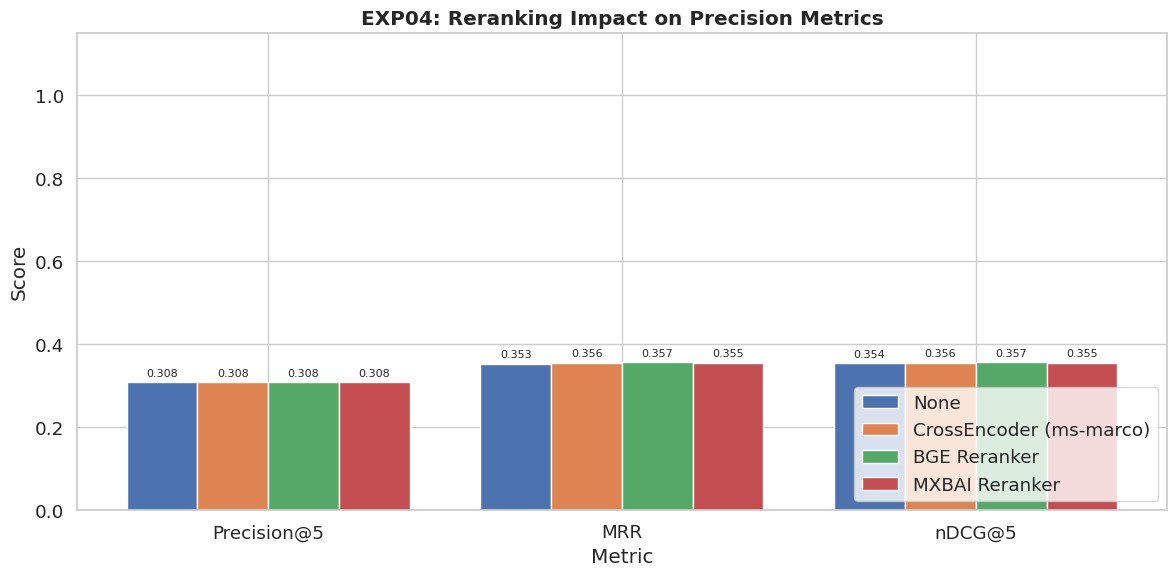

✅ Chart saved: exp04_reranking_metrics.png


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.2)

metric_cols = ["Precision@5", "MRR", "nDCG@5"]
reranker_names = list(results.keys())

x = np.arange(len(metric_cols))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

for i, name in enumerate(reranker_names):
    values = [results[name][m] for m in metric_cols]
    bars = ax.bar(x + i * width, values, width, label=name)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8,
        )

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("EXP04: Reranking Impact on Precision Metrics", fontweight="bold")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.15)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("exp04_reranking_metrics.png", dpi=150)
plt.show()

print("✅ Chart saved: exp04_reranking_metrics.png")

####5.  Latency

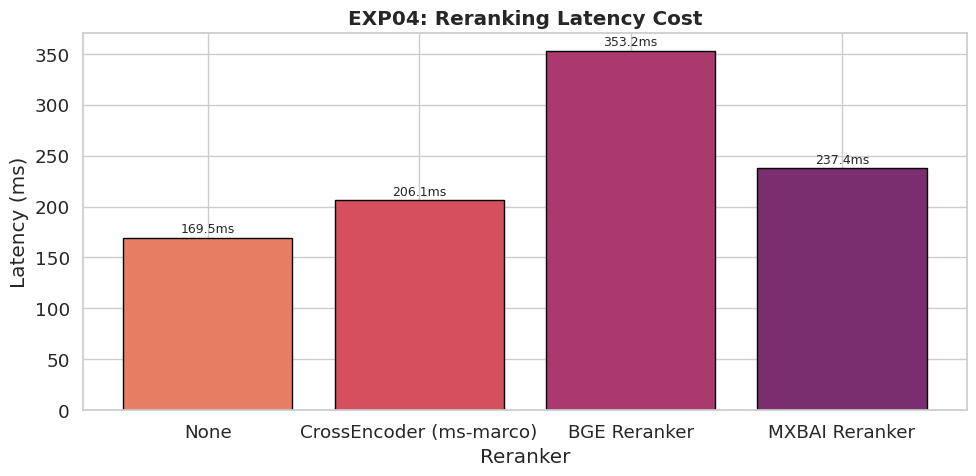

✅ Chart saved: exp04_reranking_latency.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

latencies = [results[r]["Latency (ms)"] for r in reranker_names]
colors = sns.color_palette("flare", len(reranker_names))

bars = ax.bar(reranker_names, latencies, color=colors, edgecolor="black")

for bar, val in zip(bars, latencies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{val:.1f}ms",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xlabel("Reranker")
ax.set_ylabel("Latency (ms)")
ax.set_title("EXP04: Reranking Latency Cost", fontweight="bold")

plt.tight_layout()
plt.savefig("exp04_reranking_latency.png", dpi=150)
plt.show()

print("✅ Chart saved: exp04_reranking_latency.png")

#### 6. Latency vs Precision

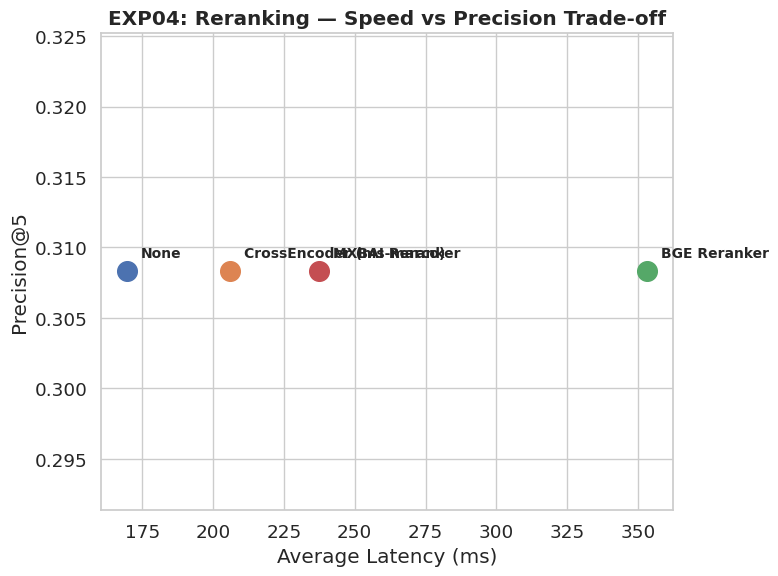

✅ Chart saved: exp04_latency_vs_precision.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

for name in reranker_names:
    latency = results[name]["Latency (ms)"]
    precision = results[name]["Precision@5"]
    ax.scatter(latency, precision, s=200, zorder=5)
    ax.annotate(
        name,
        (latency, precision),
        textcoords="offset points",
        xytext=(10, 10),
        fontsize=10,
        fontweight="bold",
    )

ax.set_xlabel("Average Latency (ms)")
ax.set_ylabel("Precision@5")
ax.set_title("EXP04: Reranking — Speed vs Precision Trade-off", fontweight="bold")

plt.tight_layout()
plt.savefig("exp04_latency_vs_precision.png", dpi=150)
plt.show()

print("✅ Chart saved: exp04_latency_vs_precision.png")

#### Cleanup

In [17]:
cloud_client.delete_collection(COLLECTION)
print(f"✅ Collection '{COLLECTION}' deleted")

✅ Collection 'exp04_reranking' deleted
